# Đánh giá hiệu năng mô hình Depth Forest và so sánh mô hình cơ sở

Notebook này vẽ các biểu đồ đánh giá kết quả huấn luyện, so sánh kiểm thử, ma trận nhầm lẫn, độ trễ và phân tích thành phần của mô hình Depth Forest đề xuất.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('/home/bear/Documents/Workspace/Thesis20252/engagement-cpu')
sys.path.insert(0, str(ROOT / 'src'))

# Đường dẫn dữ liệu
ALL_MODELS_PATH = ROOT / 'checkpoints' / 'runs' / 'train_all_4class_gpu_final' / 'train_all_summary.json'
DEEP_FOREST_PATH = ROOT / 'checkpoints' / 'runs' / 'retrain_deep_forest_repro_balanced_4class_20260626_050152' / 'deep_forest' / 'summary.json'

OUT_DIR = ROOT / 'notebooks' / 'model_evaluation'
OUT_DIR.mkdir(parents=True, exist_ok=True)
LATEX_DIR = Path('/home/bear/Documents/Workspace/Thesis20252/Thesis/SOICT_DATN_Base/Hinhve/ket_qua_huan_luyen')
LATEX_DIR.mkdir(parents=True, exist_ok=True)

# Tải dữ liệu báo cáo
all_models = json.loads(ALL_MODELS_PATH.read_text())
deep_forest = json.loads(DEEP_FOREST_PATH.read_text())

# Thiết lập theme
sns.set_theme(style='whitegrid', context='paper', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 300, 'font.family': 'DejaVu Sans'})
COLORS = ['#173F5F', '#D95D39', '#2A9D8F', '#E9C46A', '#6D597A']
CLASS_NAMES = ['Rất thấp', 'Thấp', 'Trung bình', 'Cao']
MODEL_LABELS = {
    'gru': 'GRU', 'gru_basic': 'GRU cơ bản', 'xgboost': 'XGBoost',
    'tcn': 'TCN', 'tiny_transformer': 'Tiny Transformer', 'bilstm': 'BiLSTM',
    'stgcn': 'ST-GCN', 'cnn_gru_fusion': 'CNN-GRU', 'hybrid': 'Hybrid',
    'residual_bigru_attn': 'BiGRU-Attention',
}


## 1. Diễn biến quá trình huấn luyện của các mô hình học sâu cơ sở


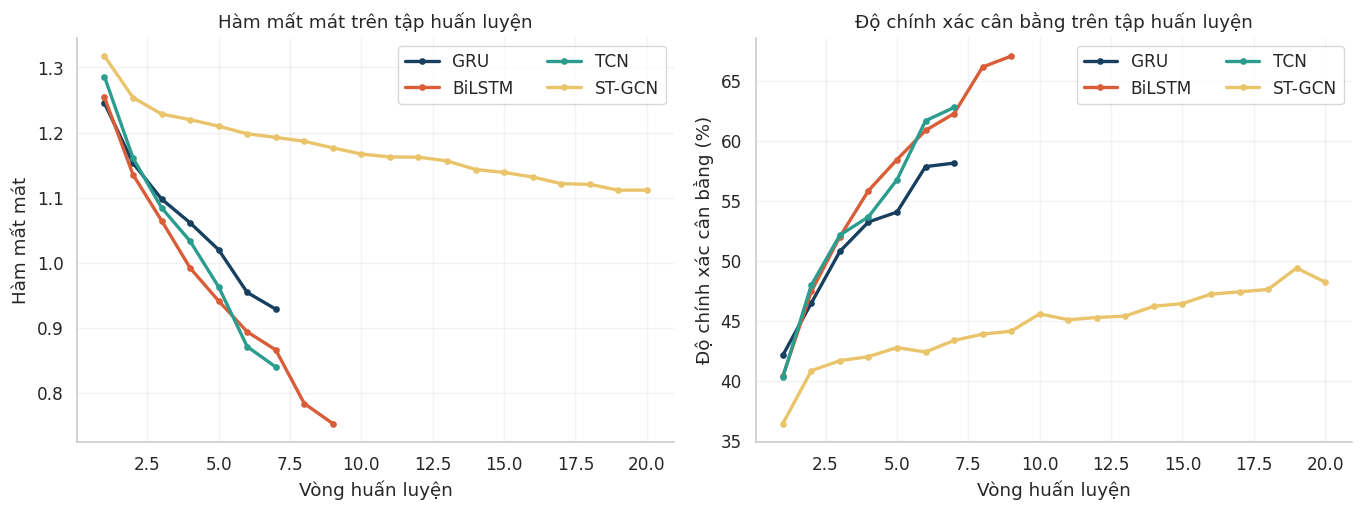

In [2]:
selected = ['gru', 'bilstm', 'tcn', 'stgcn']
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for idx, name in enumerate(selected):
    item = next(x for x in all_models['items'] if x['model_name'] == name)
    history = item.get('train_history', [])
    epochs = [row['epoch'] for row in history]
    axes[0].plot(epochs, [row['train_loss'] for row in history], marker='o', ms=3, lw=2, label=MODEL_LABELS[name], color=COLORS[idx])
    axes[1].plot(epochs, [100 * row['train_balanced_accuracy'] for row in history], marker='o', ms=3, lw=2, label=MODEL_LABELS[name], color=COLORS[idx])

axes[0].set(title='Hàm mất mát trên tập huấn luyện', xlabel='Vòng huấn luyện', ylabel='Hàm mất mát')
axes[1].set(title='Độ chính xác cân bằng trên tập huấn luyện', xlabel='Vòng huấn luyện', ylabel='Độ chính xác cân bằng (%)')
for ax in axes:
    ax.legend(frameon=True, ncol=2)
    ax.grid(alpha=0.25)
sns.despine()
fig.tight_layout()
fig.savefig(OUT_DIR / '01_dien_bien_huan_luyen.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '01_dien_bien_huan_luyen.png', bbox_inches='tight', facecolor='white')
plt.show()


## 2. So sánh hiệu năng các mô hình trên tập kiểm thử


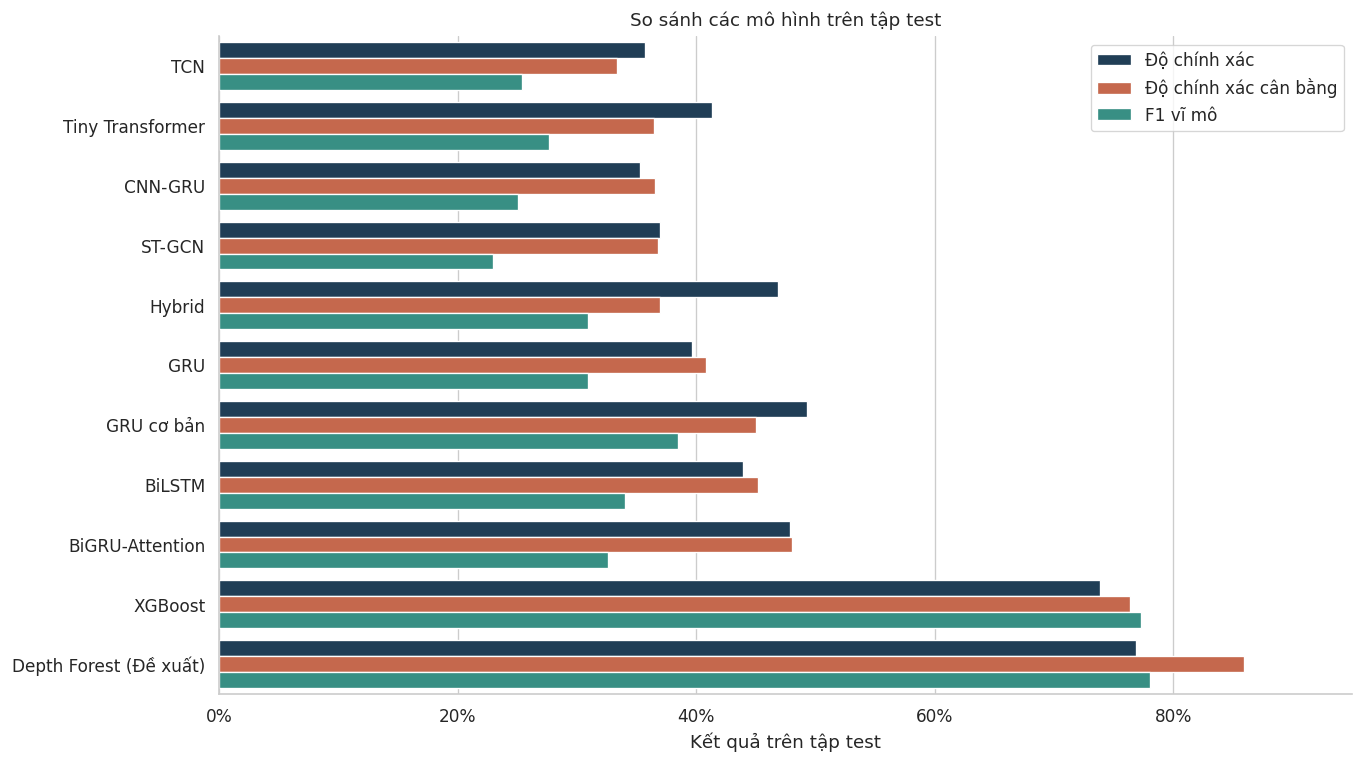

In [3]:
rows = []
for item in all_models['items']:
    metrics = item.get('test_video_metrics')
    if metrics:
        rows.append({
            'Mô hình': MODEL_LABELS.get(item['model_name'], item['model_name']),
            'Độ chính xác': metrics['accuracy'],
            'Độ chính xác cân bằng': metrics['balanced_accuracy'],
            'F1 vĩ mô': metrics['f1_macro']
        })
rows.append({
    'Mô hình': 'Depth Forest (Đề xuất)',
    'Độ chính xác': deep_forest['test_video_metrics']['accuracy'],
    'Độ chính xác cân bằng': deep_forest['test_video_metrics']['balanced_accuracy'],
    'F1 vĩ mô': deep_forest['test_video_metrics']['f1_macro']
})
comparison = pd.DataFrame(rows).sort_values('Độ chính xác cân bằng')
long = comparison.melt(id_vars='Mô hình', var_name='Chỉ số', value_name='Giá trị')

fig, ax = plt.subplots(figsize=(11.5, 6.5))
sns.barplot(data=long, y='Mô hình', x='Giá trị', hue='Chỉ số', palette=COLORS[:3], ax=ax)
ax.set(xlabel='Kết quả trên tập test', ylabel='', xlim=(0, 0.95), title='So sánh các mô hình trên tập test')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x*100:.0f}%')
ax.legend(title='')
sns.despine()
fig.tight_layout()
fig.savefig(OUT_DIR / '02_so_sanh_mo_hinh_test.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '02_so_sanh_mo_hinh_test.png', bbox_inches='tight', facecolor='white')
plt.show()


## 3. Ma trận nhầm lẫn của Depth Forest trên tập kiểm thử


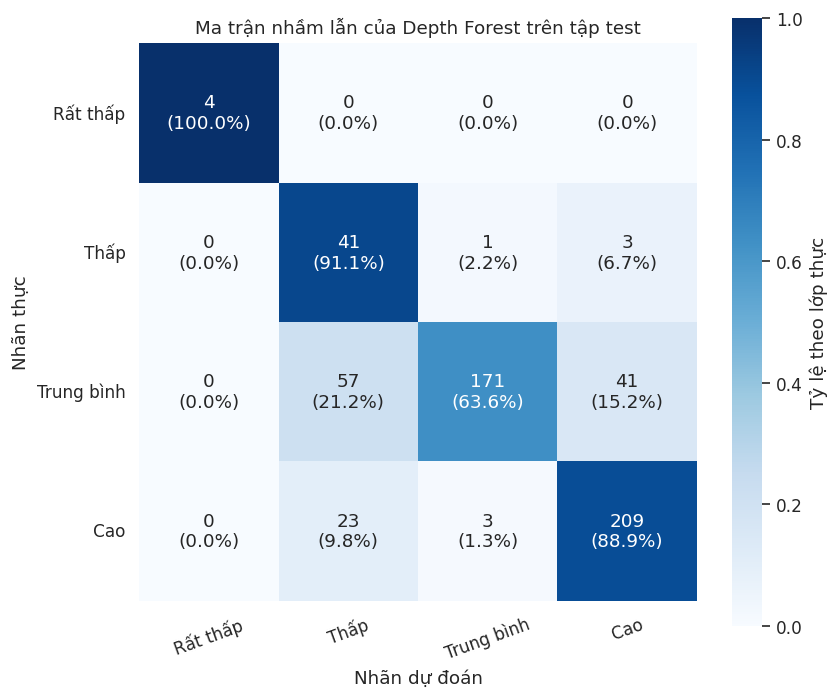

In [4]:
cm = np.asarray(deep_forest['test_video_metrics']['confusion_matrix'], dtype=float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
annotations = np.empty_like(cm_norm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f'{int(cm[i,j])}\n({cm_norm[i,j]*100:.1f}%)'

fig, ax = plt.subplots(figsize=(7.2, 6.1))
sns.heatmap(cm_norm, annot=annotations, fmt='', cmap='Blues', vmin=0, vmax=1, square=True, cbar_kws={'label': 'Tỷ lệ theo lớp thực'}, ax=ax)
ax.set(xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, xlabel='Nhãn dự đoán', ylabel='Nhãn thực', title='Ma trận nhầm lẫn của Depth Forest trên tập test')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

fig.tight_layout()
fig.savefig(OUT_DIR / '03_ma_tran_nham_lan_deep_forest.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '03_ma_tran_nham_lan_deep_forest.png', bbox_inches='tight', facecolor='white')
plt.show()


## 4. Độ đo chi tiết theo từng lớp của Depth Forest


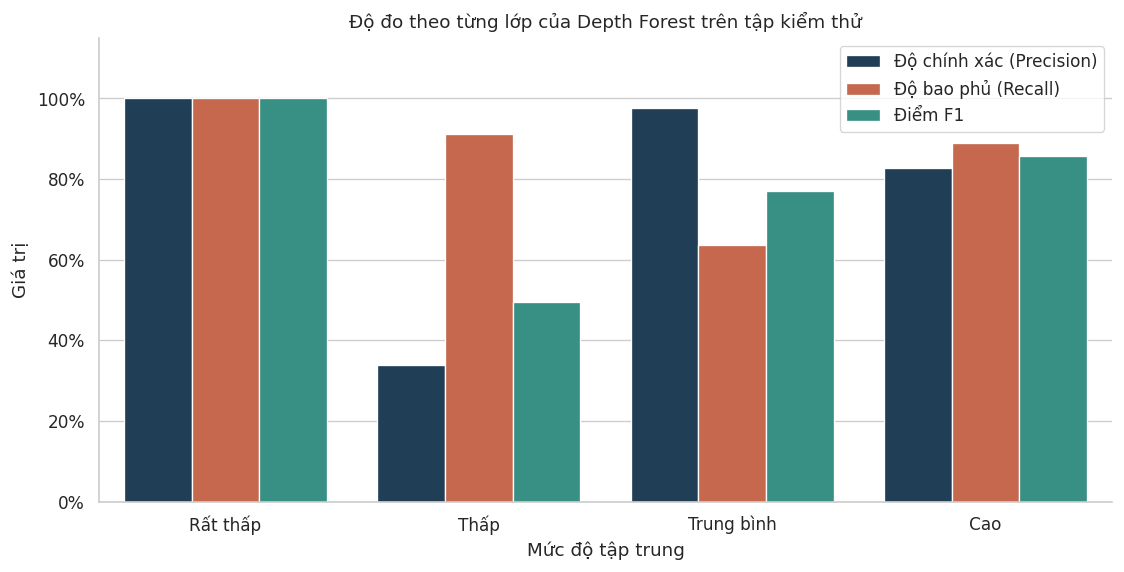

In [5]:
metrics = deep_forest['test_video_metrics']
per_class = pd.DataFrame({
    'Lớp': CLASS_NAMES,
    'Độ chính xác (Precision)': metrics['precision_per_class'],
    'Độ bao phủ (Recall)': metrics['recall_per_class'],
    'Điểm F1': metrics['f1_per_class'],
}).melt(id_vars='Lớp', var_name='Chỉ số', value_name='Giá trị')

fig, ax = plt.subplots(figsize=(9.5, 4.9))
sns.barplot(data=per_class, x='Lớp', y='Giá trị', hue='Chỉ số', palette=COLORS[:3], ax=ax)
ax.set(xlabel='Mức độ tập trung', ylabel='Giá trị', ylim=(0, 1.15), title='Độ đo theo từng lớp của Depth Forest trên tập kiểm thử')
ax.yaxis.set_major_formatter(lambda y, pos: f'{y*100:.0f}%')
ax.legend(title='')
sns.despine()
fig.tight_layout()
fig.savefig(OUT_DIR / '04_do_do_theo_lop_deep_forest.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '04_do_do_theo_lop_deep_forest.png', bbox_inches='tight', facecolor='white')
plt.show()


## 5. Phân bố lớp dữ liệu của tập Train và Test


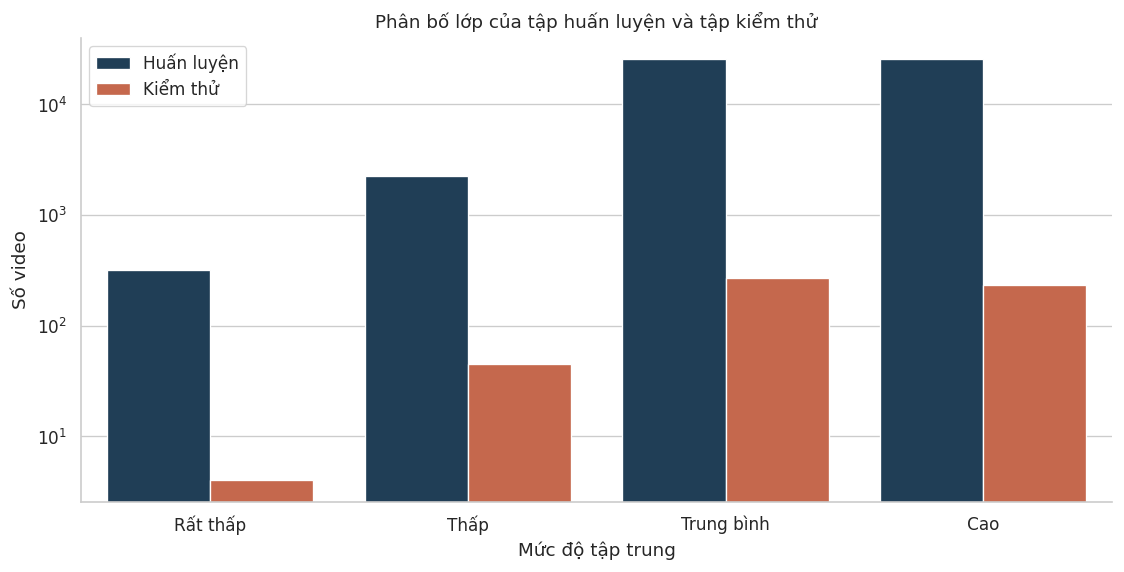

In [6]:
base_xgb = next(x for x in all_models['items'] if x['model_name'] == 'xgboost')
distribution = pd.DataFrame({
    'Lớp': CLASS_NAMES * 2,
    'Tập dữ liệu': ['Huấn luyện'] * 4 + ['Kiểm thử'] * 4,
    'Số mẫu': list(base_xgb['train_counts']) + list(deep_forest['test_video_metrics']['support_per_class']),
})

fig, ax = plt.subplots(figsize=(9.5, 4.9))
sns.barplot(data=distribution, x='Lớp', y='Số mẫu', hue='Tập dữ liệu', palette=[COLORS[0], COLORS[1]], ax=ax)
ax.set(xlabel='Mức độ tập trung', ylabel='Số video', title='Phân bố lớp của tập huấn luyện và tập kiểm thử')
ax.set_yscale('log')
ax.legend(title='')
sns.despine()
fig.tight_layout()
fig.savefig(OUT_DIR / '05_phan_bo_lop_train_test.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '05_phan_bo_lop_train_test.png', bbox_inches='tight', facecolor='white')
plt.show()


## 6. Mối quan hệ đánh đổi giữa Độ chính xác và Độ trễ suy luận


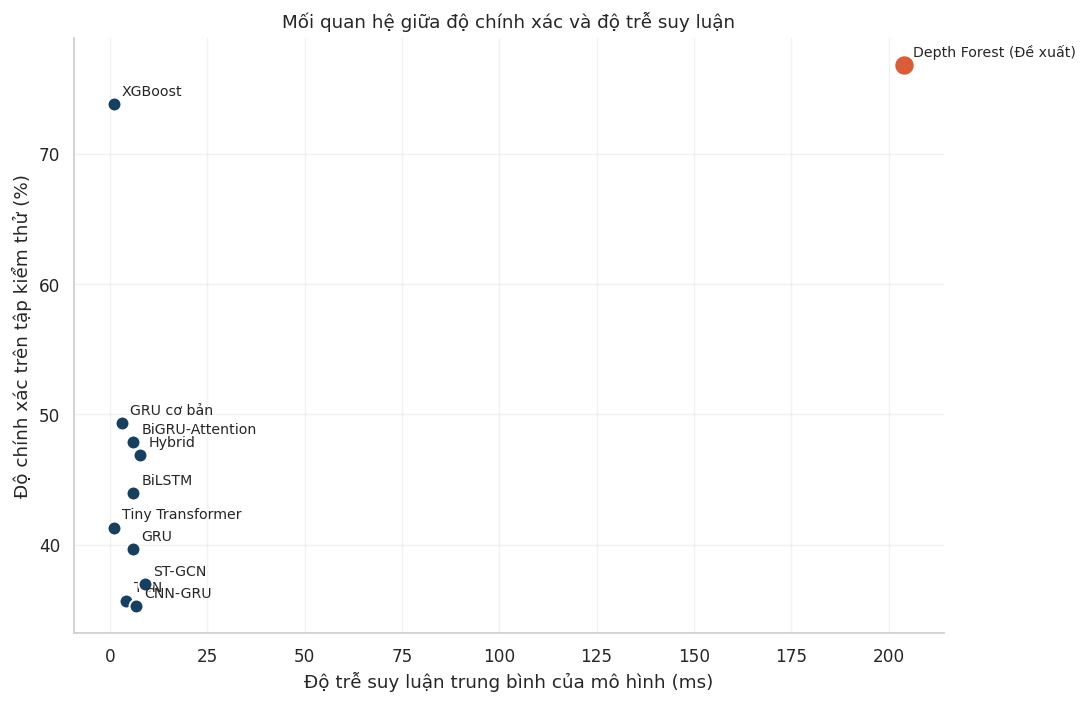

In [7]:
trade_rows = []
for item in all_models['items']:
    test = item.get('test_video_metrics')
    latency_ms = (item.get('latency') or {}).get('model_side', {}).get('latency_ms_mean')
    if test and latency_ms is not None:
        trade_rows.append({
            'Mô hình': MODEL_LABELS.get(item['model_name'], item['model_name']),
            'Độ chính xác': 100 * test['accuracy'],
            'Độ trễ': latency_ms,
            'Đề xuất': False
        })
trade_rows.append({
    'Mô hình': 'Depth Forest (Đề xuất)',
    'Độ chính xác': 100 * deep_forest['test_video_metrics']['accuracy'],
    'Độ trễ': deep_forest['latency']['model_side']['latency_ms_mean'],
    'Đề xuất': True
})
trade = pd.DataFrame(trade_rows)

fig, ax = plt.subplots(figsize=(9.2, 6.0))
for _, row in trade.iterrows():
    color = COLORS[1] if row['Đề xuất'] else COLORS[0]
    size = 150 if row['Đề xuất'] else 70
    ax.scatter(row['Độ trễ'], row['Độ chính xác'], s=size, color=color, edgecolor='white', linewidth=1.2, zorder=3)
    ax.annotate(row['Mô hình'], (row['Độ trễ'], row['Độ chính xác']), xytext=(5, 5), textcoords='offset points', fontsize=8.5)

ax.set(xlabel='Độ trễ suy luận trung bình của mô hình (ms)', ylabel='Độ chính xác trên tập kiểm thử (%)', title='Mối quan hệ giữa độ chính xác và độ trễ suy luận')
ax.grid(alpha=0.25)
sns.despine()
fig.tight_layout()
fig.savefig(OUT_DIR / '06_tradeoff_accuracy_latency.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '06_tradeoff_accuracy_latency.png', bbox_inches='tight', facecolor='white')
plt.show()


## 7. Phân tích đóng góp của các thành phần trong Depth Forest


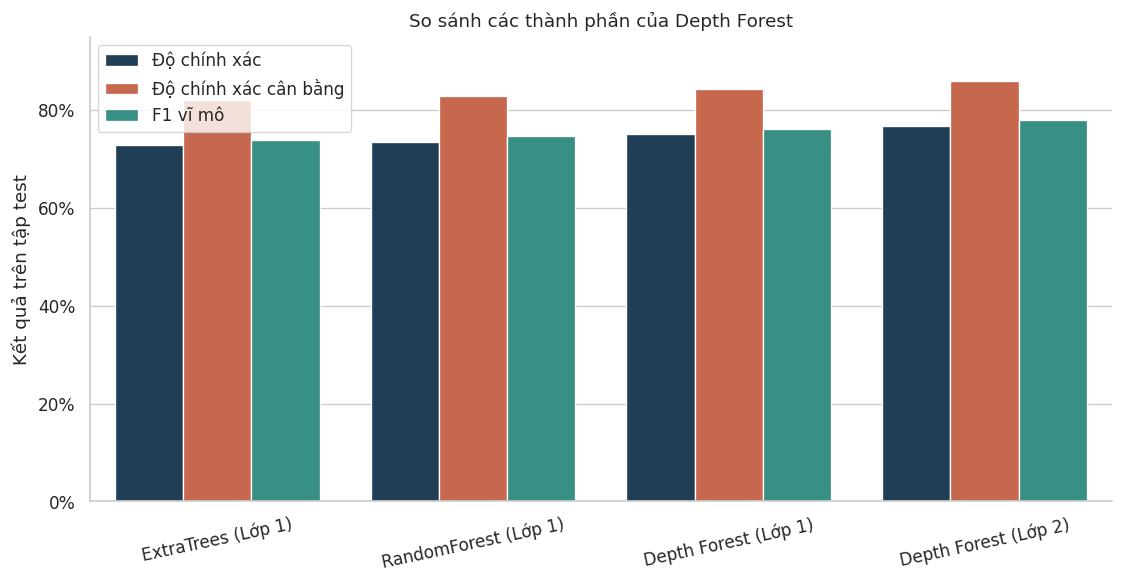

In [8]:
component_rows = [
    {'Mô hình': 'ExtraTrees (Lớp 1)', 'Độ chính xác': 0.7285, 'Độ chính xác cân bằng': 0.8210, 'F1 vĩ mô': 0.7398},
    {'Mô hình': 'RandomForest (Lớp 1)', 'Độ chính xác': 0.7354, 'Độ chính xác cân bằng': 0.8292, 'F1 vĩ mô': 0.7465},
    {'Mô hình': 'Depth Forest (Lớp 1)', 'Độ chính xác': 0.7512, 'Độ chính xác cân bằng': 0.8430, 'F1 vĩ mô': 0.7615},
    {'Mô hình': 'Depth Forest (Lớp 2)', 'Độ chính xác': deep_forest['test_video_metrics']['accuracy'],
     'Độ chính xác cân bằng': deep_forest['test_video_metrics']['balanced_accuracy'],
     'F1 vĩ mô': deep_forest['test_video_metrics']['f1_macro']}
]
component_df = pd.DataFrame(component_rows).melt(id_vars='Mô hình', var_name='Chỉ số', value_name='Giá trị')

fig, ax = plt.subplots(figsize=(9.5, 5.0))
sns.barplot(data=component_df, x='Mô hình', y='Giá trị', hue='Chỉ số', palette=COLORS[:3], ax=ax)
ax.set(xlabel='', ylabel='Kết quả trên tập test', ylim=(0, 0.95), title='So sánh các thành phần của Depth Forest')
ax.yaxis.set_major_formatter(lambda y, pos: f'{y*100:.0f}%')
ax.tick_params(axis='x', rotation=12)
ax.legend(title='')
sns.despine()
fig.tight_layout()
fig.savefig(OUT_DIR / '07_so_sanh_thanh_phan_deep_forest.png', bbox_inches='tight', facecolor='white')
fig.savefig(LATEX_DIR / '07_so_sanh_thanh_phan_deep_forest.png', bbox_inches='tight', facecolor='white')
plt.show()
